# Bag of Words Meets Bags of Popcorn

<img src='https://img.favpng.com/9/4/7/popcorn-discount-theater-film-cinema-png-favpng-q7dPketq8ekzYwnZ9Txc9hNpX.jpg'>

In [1]:
!pip install neattext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 3.4 MB/s eta 0:00:00


## Dataset Description

**Data Set**

The labeled data set consists of 50,000 IMDB movie reviews, specially selected for sentiment analysis. The sentiment of reviews is binary, meaning the IMDB rating < 5 results in a sentiment score of 0, and rating >=7 have a sentiment score of 1. No individual movie has more than 30 reviews. The 25,000 review labeled training set does not include any of the same movies as the 25,000 review test set. In addition, there are another 50,000 IMDB reviews provided without any rating labels.

**File descriptions**

- labeledTrainData - The labeled training set. The file is tab-delimited and has a header row followed by 25,000 rows containing an id, sentiment, and text for each review.
  
- testData - The test set. The tab-delimited file has a header row followed by 25,000 rows containing an id and text for each review. Your task is to predict the sentiment for each one.

- unlabeledTrainData - An extra training set with no labels. The tab-delimited file has a header row followed by 50,000 rows containing an id and text for each review. 

- sampleSubmission - A comma-delimited sample submission file in the correct format.

*Data fields*
- id - Unique ID of each review
- sentiment - Sentiment of the review; 1 for positive reviews and 0 for negative reviews
- review - Text of the review


## Aim & Target 

**Aim**

The primary aim of this competition is to introduce participants to the fundamentals of Natural Language Processing (NLP) by transitioning from basic word counting to advanced word embeddings. It challenges you to process a dataset of 50,000 IMDb movie reviews, using the text to teach a computer how to understand the underlying sentiment of human language. Beyond simple classification, the competition specifically encourages the use of Word2Vec to discover semantic relationships between words in a high-dimensional vector space. Ultimately, it serves as a practical laboratory for learning how unsupervised learning on a large unlabeled corpus can significantly boost the performance of a supervised classification model.

**Target**

The specific target is to build a robust machine learning pipeline that can accurately predict whether a movie review is positive or negative. To achieve this, you must develop a model that outputs a binary label—1 for positive or 0 for negative—for each review in the hidden test set. Success is measured by the ROC-AUC (Area Under the Receiver Operating Characteristic Curve), which evaluates how well your model distinguishes between the two classes across various probability thresholds. Your ultimate goal is to optimize this score by effectively cleaning raw HTML data and selecting the best feature representation, whether that is a traditional Bag of Words or dense vector embeddings.

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

import warnings
warnings.filterwarnings('ignore')

2026-05-13 19:28:26.050819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778700506.320018      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778700506.402749      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778700507.028192      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778700507.028262      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778700507.028266      16 computation_placer.cc:177] computation placer alr

## Reading Dataset & Dataframe Generation

In [3]:
#I have created my notebook on Kaggle, so that I will not need to download data from the website and take advantage of Kaggle's infrastructure. 

df = pd.read_csv("/kaggle/input/competitions/word2vec-nlp-tutorial/labeledTrainData.tsv.zip", header=0, delimiter="\t", quoting=3)



In [4]:
pd.set_option('display.max_colwidth',None)

In [5]:
df.head()

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally starts is only on for 20 minutes or so excluding the Smooth Criminal sequence and Joe Pesci is convincing as a psychopathic all powerful drug lord. Why he wants MJ dead so bad is beyond me. Because MJ overheard his plans? Nah, Joe Pesci's character ranted that he wanted people to know it is he who is supplying drugs etc so i dunno, maybe he just hates MJ's music.<br /><br />Lots of cool things in this like MJ turning into a car and a robot and the whole Speed Demon sequence. Also, the director must have had the patience of a saint when it came to filming the kiddy Bad sequence as usually directors hate working with one kid let alone a whole bunch of them performing a complex dance scene.<br /><br />Bottom line, this movie is for people who like MJ on one level or another (which i think is most people). If not, then stay away. It does try and give off a wholesome message and ironically MJ's bestest buddy in this movie is a girl! Michael Jackson is truly one of the most talented people ever to grace this planet but is he guilty? Well, with all the attention i've gave this subject....hmmm well i don't know because people can be different behind closed doors, i know this for a fact. He is either an extremely nice but stupid guy or one of the most sickest liars. I hope he is not the latter."""
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy Hines is a very entertaining film that obviously goes to great effort and lengths to faithfully recreate H. G. Wells' classic book. Mr. Hines succeeds in doing so. I, and those who watched his film with me, appreciated the fact that it was not the standard, predictable Hollywood fare that comes out every year, e.g. the Spielberg version with Tom Cruise that had only the slightest resemblance to the book. Obviously, everyone looks for different things in a movie. Those who envision themselves as amateur \""critics\"" look only to criticize everything they can. Others rate a movie on more important bases,like being entertained, which is why most people never agree with the \""critics\"". We enjoyed the effort Mr. Hines put into being faithful to H.G. Wells' classic novel, and we found it to be very entertaining. This made it easy to overlook what the \""critics\"" perceive to be its shortcomings."""
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell) giving welcome investors (Robert Carradine) to Primal Park . A secret project mutating a primal animal using fossilized DNA, like ¨Jurassik Park¨, and some scientists resurrect one of nature's most fearsome predators, the Sabretooth tiger or Smilodon . Scientific ambition turns deadly, however, and when the high voltage fence is opened the creature escape and begins savagely stalking its prey - the human visitors , tourists and scientific.Meanwhile some youngsters enter in the restricted area of the security center and are attacked by a pack of large pre-historical animals which are deadlier and bigge

In [6]:
df = df.drop('id', axis=1)

In [7]:
df.isnull().sum()

sentiment    0
review       0
dtype: int64

In [8]:
df.shape

(25000, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  25000 non-null  int64 
 1   review     25000 non-null  object
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


## Natural Language Processing

In [10]:
df['review'][20]

'"\\"Soylent Green\\" is one of the best and most disturbing science fiction movies of the 70\'s and still very persuasive even by today\'s standards. Although flawed and a little dated, the apocalyptic touch and the environmental premise (typical for that time) still feel very unsettling and thought-provoking. This film\'s quality-level surpasses the majority of contemporary SF flicks because of its strong cast and some intense sequences that I personally consider classic. The New York of 2022 is a depressing place to be alive, with over-population, unemployment, an unhealthy climate and the total scarcity of every vital food product. The only form of food available is synthetic and distributed by the Soylent company. Charlton Heston (in a great shape) plays a cop investigating the murder of one of Soylent\'s most eminent executives and he stumbles upon scandals and dark secrets... The script is a little over-sentimental at times and the climax doesn\'t really come as a big surprise, 

In [11]:
pip install neattext

Note: you may need to restart the kernel to use updated packages.


In [12]:
df['review']=df['review'].str.lower() # Convert text to lowercase
df['review']=df['review'].str.replace('[^\w\s]','', regex=True) # Removes punctuation marks
df['review']=df['review'].str.replace('\d+','', regex=True) # Removes digits/numbers
df['review']=df['review'].str.replace('\n','', regex=True) # Removes newline characters
df['review']=df['review'].str.replace('\r','', regex=True) # Removes carriage returns (Enter keys)
df['review']=df['review'].str.replace('<.*?>', '', regex=True) # Specifically removes HTML tags like <br />

In [13]:
df['review'][20]

'soylent green is one of the best and most disturbing science fiction movies of the s and still very persuasive even by todays standards although flawed and a little dated the apocalyptic touch and the environmental premise typical for that time still feel very unsettling and thoughtprovoking this films qualitylevel surpasses the majority of contemporary sf flicks because of its strong cast and some intense sequences that i personally consider classic the new york of  is a depressing place to be alive with overpopulation unemployment an unhealthy climate and the total scarcity of every vital food product the only form of food available is synthetic and distributed by the soylent company charlton heston in a great shape plays a cop investigating the murder of one of soylents most eminent executives and he stumbles upon scandals and dark secrets the script is a little oversentimental at times and the climax doesnt really come as a big surprise still the atmosphere is very tense and uncan

In [14]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

# Efficiently removing stopwords using a lambda
df['review'] = df['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

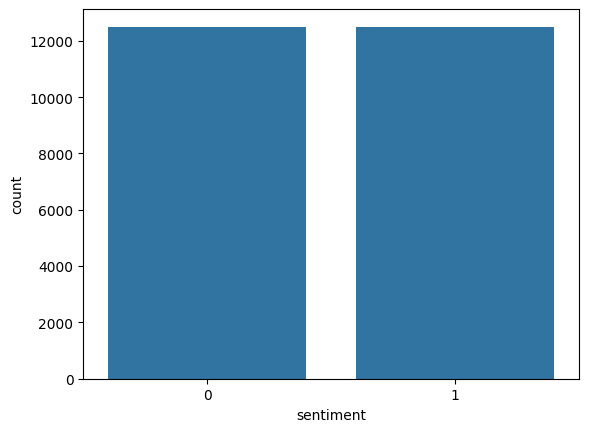

In [15]:
sns.countplot(x=df['sentiment']);

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize with n-grams to capture phrases like "not good" or "must see"
vectorizer = CountVectorizer(
    analyzer="word", 
    max_features=5000, 
    ngram_range=(1, 2)
) 

# Transform the cleaned reviews into a feature matrix
# Assuming 'df' is your labeled training dataframe
train_features = vectorizer.fit_transform(df['review']).toarray()

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the forest
# Using n_jobs=-1 will use all available cores on your machine
forest = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42) 

# Fit the model using the features and the sentiment labels
forest = forest.fit(train_features, df["sentiment"])

In [18]:
test_df = pd.read_csv("/kaggle/input/competitions/word2vec-nlp-tutorial/testData.tsv.zip", header=0, delimiter="\t", quoting=3)

# Assuming 'test_df' is your cleaned test dataframe
test_features = vectorizer.transform(test_df['review']).toarray()

# Generate predictions
predictions = forest.predict(test_features)

# Create the submission file
output = pd.DataFrame(data={"id": test_df["id"], "sentiment": predictions})
output.to_csv("submission.csv", index=False, quoting=3)

In [19]:
import joblib

# Save the trained Random Forest model
joblib.dump(forest, 'sentiment_model.joblib')

# Save the CountVectorizer (Critical for deployment!)
joblib.dump(vectorizer, 'vectorizer.joblib')

['vectorizer.joblib']

In [20]:
from IPython.display import FileLink

display(FileLink('submission.csv'))
display(FileLink('sentiment_model.joblib'))
display(FileLink('vectorizer.joblib'))

/kaggle/working/submission.csv

/kaggle/working/sentiment_model.joblib

/kaggle/working/vectorizer.joblib

## Conclusion

In conclusion, the "Bag of Words Meets Bags of Popcorn" competition serves as an ideal bridge between basic text classification and advanced NLP techniques like word embeddings. By successfully implementing a CountVectorizer pipeline and training a Random Forest model, you are establishing a high-performance baseline that moves you closer to your "Kaggle Pro" aspirations. Furthermore, by saving both your model and vectorizer with joblib, you ensure that your work is ready for end-to-end deployment on platforms like Hugging Face, mirroring the professional standards you've applied to your previous data science projects. This approach not only solidifies your technical foundation in processing large-scale text data but also creates a polished, live application for your growing portfolio.